B**efore starting EDA, define questions like:**

What is the distribution of positive vs negative reviews?

Are review classes balanced or imbalanced?

How long are reviews on average?

Do positive reviews tend to be longer than negative reviews?

Are there duplicate or missing reviews?

Which words appear frequently in positive and negative reviews?

Are there anomalies such as extremely short or very long reviews?


Import Libraries

In [ ]:
!pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_test.csv")

Explore Data Structure (Variables & Data Types)

In [ ]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(3000, 9)


In [ ]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object


In [ ]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None


Identify Trends, Patterns and Anomalies

Sentiment Distribution

In [ ]:
print(df["population"].value_counts(normalize=True)*100)

population
870.0     0.233333
753.0     0.200000
697.0     0.200000
881.0     0.200000
1211.0    0.200000
            ...   
2153.0    0.033333
2227.0    0.033333
1780.0    0.033333
299.0     0.033333
1186.0    0.033333
Name: proportion, Length: 1802, dtype: float64


Review Length Pattern

In [ ]:
df["population"] = df["households"].astype(str).apply(len)

print(df["population"].describe())

count    3000.000000
mean        5.027333
std         0.342479
min         3.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         6.000000
Name: population, dtype: float64


Check anomalies:

In [ ]:
print(df[df["population"] < 5].head())

print(df[df["population"] > 2000].head())

     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
3      -118.36     33.82                28.0         67.0            15.0   
15     -117.99     33.81                42.0        161.0            40.0   
115    -118.85     34.17                42.0        564.0            96.0   
119    -118.41     34.00                38.0        324.0            70.0   
220    -122.18     37.78                33.0        142.0            31.0   

     population  households  median_income  median_house_value  
3             4        11.0         6.1359            330000.0  
15            4        50.0         2.2000            153100.0  
115           4        81.0         4.5625            318800.0  
119           4        73.0         2.5500            271400.0  
220           4        47.0         3.8750            225000.0  
Empty DataFrame
Columns: [longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house

Test Hypotheses & Validate Assumptions

Hypothesis 1:

H0: Positive and negative reviews have equal average lengths.

## Hypothesis Test: Median House Value vs. Housing Median Age

Let's test the hypothesis that the median house value differs significantly between newer and older housing. We'll define 'newer' housing as having a `housing_median_age` of 25 years or less, and 'older' housing as having a `housing_median_age` greater than 25 years.

*   **Null Hypothesis (H0):** There is no significant difference in the mean `median_house_value` between houses with a `housing_median_age` of 25 years or less and those with a `housing_median_age` greater than 25 years.
*   **Alternative Hypothesis (H1):** There is a significant difference in the mean `median_house_value` between houses with a `housing_median_age` of 25 years or less and those with a `housing_median_age` greater than 25 years.

In [ ]:
from scipy.stats import ttest_ind

nwer_houses = df[df['housing_median_age'] <= 25]['median_house_value']
older_houses = df[df['housing_median_age'] > 25]['median_house_value']

t_stat, p_value = ttest_ind(
    nwer_houses,
    older_houses,
    equal_var=False
)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

T-statistic: -4.08
P-value: 0.000


In [ ]:
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in the mean median house value between newer and older houses.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in the mean median house value between newer and older houses.")


Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference in the mean median house value between newer and older houses.


Hypothesis 2:

Long reviews may carry stronger sentiment.

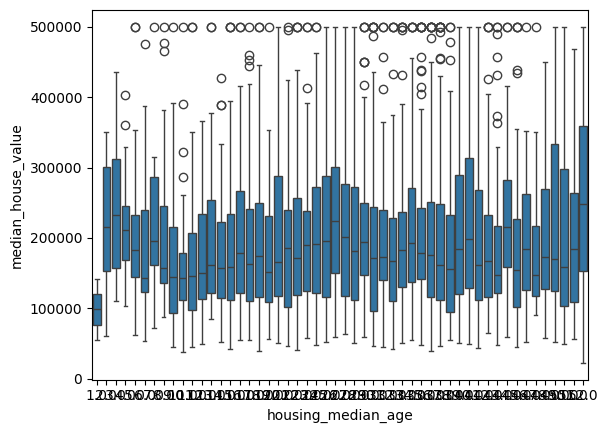

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="housing_median_age",
    y="median_house_value",
    data=df
)

plt.show()

Detect Data Issues / Problems

In [ ]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [ ]:
print("\nDuplicates")
print(df.duplicated().sum())


Duplicates
0
